<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Earth Analysis 1 — Earth Geometry and Density Profiles
---

This notebook is dedicated to the **internal structure, geometry, and electron-density models** of the Earth as used in the tpeanuts matter-regeneration pipeline. It covers the two available density models (even-power polynomial and PREM tabulated), their layer structure and shell representations, the chord geometry for neutrino trajectories as a function of nadir angle, and the derived physical quantities — column density and matter potential — that connect the density profile to the MSW oscillation Hamiltonian.

---

## Table of Contents

| # | Section |
|---|----------|
| [0](#0.-Theory-Background) | **Theory Background**: PREM, Earth layers, chord geometry, matter potential |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Configuration) | **Configuration** — paths, layer constants |
| [3](#3.-Electron-Density-Profiles) | **Electron Density Profiles** — radial profile, shells, residuals, $V_{\rm mat}(r)$ |
| [4](#4.-Earth-Layer-Anatomy) | **Earth Layer Anatomy** — geophysical layers, per-layer density |
| [5](#5.-Chord-Geometry) | **Chord Geometry** — critical angles, 2D diagram, $L(\eta)$, density along chord |
| [6](#6.-Path-Length-and-Column-Density) | **Path Length and Column Density** — per-layer lengths, $\int n_e\,dl$ |
| [7](#7.-2D-Density-Cross-Section) | **2D Density Cross-Section** — $n_e(x,y)$ map |
| [8](#8.-Summary) | **Summary** |

## 0. Theory Background

### 0.1 The PREM Model

The **Preliminary Reference Earth Model** (PREM, Dziewonski & Anderson 1981) is the standard spherically-symmetric Earth model used in geophysics. It provides mass density $\rho(r)$, seismic velocities, and pressure as functions of radius. The tpeanuts code uses PREM in two ways:

- **PREM**: 491 radial shells from the IRIS SPUD tabulation, each with density linear in $r^2$ (``PremTabulatedProfile``).
- **Even-power polynomial** (``EvenPowerProfileLayered``): a small number of broad shells each described by a polynomial $n_e(r^2) = a_0 + a_1 r^2 + a_2 r^4 + \ldots$ fit to geophysical data. Faster to evaluate but coarser near discontinuities.

The electron number density $n_e$ is related to mass density $\rho$ by
$$n_e = \left\langle\frac{Z}{A}\right\rangle N_A \rho,$$
where $\langle Z/A \rangle \approx 0.466$ for the mantle and $\approx 0.468$ for the core (Stacey 1992). In tpeanuts the tabulated $n_e$ is stored directly in mol/cm³.

---

### 0.2 Earth Internal Structure

| Layer | Depth [km] | Radius [km] | Key phase |
|-------|-----------|-------------|----------|
| Inner Core (IC) | 5150–6371 | 0–1221 | Solid Fe-Ni |
| Outer Core (OC) | 2891–5150 | 1221–3480 | Liquid Fe-Ni |
| D'' layer | 2741–2891 | 3480–3630 | Perovskite/post-perovskite |
| Lower Mantle | 660–2891 | 3480–5711 | MgSiO$_3$ perovskite |
| Transition Zone | 410–660 | 5711–5961 | Olivine $\to$ spinel |
| Upper Mantle | 24–410 | 5961–6347 | Olivine, pyroxene |
| Crust | 0–24 | 6347–6371 | Silicates |

The sharp **ICB** (Inner Core Boundary) and **CMB** (Core–Mantle Boundary) are the dominant density discontinuities and produce the strongest oscillation signatures for deeply-penetrating atmospheric neutrinos.

---

### 0.3 Chord Geometry

For a neutrino arriving at the detector with **nadir angle** $\eta$ (angle from the downward vertical):

- **Chord length**: $L(\eta) = 2R_\oplus \cos\eta$ (for a surface detector)
- **Minimum radius** (closest approach): $r_{\min}(\eta) = R_\oplus \sin\eta$
- **Critical angle** for layer boundary $r_j$: $\eta_j = \arccos(r_j/R_\oplus)$
  — only trajectories with $\eta < \eta_j$ cross into that layer.

The trajectory coordinate $x \in [-\cos\eta,\, \cos\eta]$ is related to radius by
$$r^2(x) = x^2 + \sin^2\eta,$$
so the density along the chord is $n_e(x, \eta) = n_e\bigl(\sqrt{x^2 + \sin^2\eta}\bigr)$.

---

### 0.4 Matter Potential

The charged-current (CC) matter potential for electron neutrinos, derived by Wolfenstein (1978) from coherent forward scattering on background electrons, is
$$V_{\rm CC}(r) = \sqrt{2}\,G_F\,n_e(r),$$
where $G_F$ is the **Fermi constant** — the fundamental weak-interaction coupling measured from muon decay (Workman et al. 2022):
$$G_F = 1.1663787 \times 10^{-5}\,\text{GeV}^{-2} = 1.1663787 \times 10^{-11}\,\text{MeV}^{-2}.$$
In practical units the potential becomes
$$V_{\rm CC}\,[10^{-13}\text{ eV}] = 7.637 \times 10^{-1} \times n_e\,[\text{mol/cm}^3].$$

The ratio $V_{\rm CC}/(\Delta m^2_{32}/2E)$ determines the strength of the Earth matter effect: it reaches $\mathcal{O}(1)$ for atmospheric neutrinos at $E \sim 3$–$7$ GeV traversing the Earth core, producing the MSW resonance condition $V_{\rm CC} = \cos 2\theta_{13}\,\Delta m^2_{32}/2E$.

---

**References**
- Dziewonski, A. M. & Anderson, D. L. (1981). *Preliminary reference Earth model*. Phys. Earth Planet. Inter. **25**, 297.
- Stacey, F. D. (1992). *Physics of the Earth*, 3rd ed. Brookfield Press.
- Wolfenstein, L. (1978). *Neutrino oscillations in matter*. Phys. Rev. D **17**, 2369.
- Workman, R. L. et al. (Particle Data Group) (2022). *Review of Particle Physics*. PTEP **2022**, 083C01.
- Giunti, C. & Kim, C. W. (2007). *Fundamentals of Neutrino Physics and Astrophysics*, §12. Oxford University Press.

## 1. Libraries

In [1]:
import math

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

from tpeanuts.util.context import RuntimeContext
from tpeanuts.util.type import to_numpy
import tpeanuts.util.constant as constant
from tpeanuts.medium.earth.profile import EarthParameters, EarthProfile
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show

print(f'Torch {torch.__version__}')

Torch 2.3.1


## 2. Configuration

### 2.1 Paths

`load_notebook_config()` resolves the repository root, applies the shared matplotlib/torch/numpy style, and creates the output directory. All figures from this notebook are saved under `analysis/earth/`.

In [2]:
config     = load_notebook_config()
ctx        = RuntimeContext.resolve(config.device, config.dtype)
OUTPUT_DIR = config.output_dir("analysis", "earth")

EARTH_DENSITY_CSV = config.earth_density_file
PREM_FILE      = config.prem_density_file

print(f'Package dir       : {config.package_dir}')
print(f'Output dir        : {OUTPUT_DIR}')
print(f'Earth density CSV : {EARTH_DENSITY_CSV}')
print(f'PREM file      : {PREM_FILE}')
print(f'Device            : {ctx.device}   dtype: {ctx.dtype}')

Package dir       : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Output dir        : v:\output\analysis\earth
Earth density CSV : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\density\earth_density.csv
PREM file      : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\external\PREM.csv
Device            : cpu   dtype: torch.float64


### 2.2 Earth Layer Constants

Key geophysical boundary radii, derived physical constants, and the two Earth density models. The **matter-potential conversion factor** $c_V = \sqrt{2}\,G_F\,N_A\,(\hbar c)^3$ in compatible units gives $V_{\rm CC}$ [eV] from $n_e$ [mol/cm³] directly.

| Boundary | Radius [km] | Depth [km] | Critical $\eta$ |
|----------|-------------|------------|----------------|
| ICB (Inner Core) | 1221.5 | 5149.5 | computed in §5 |
| CMB (Core–Mantle) | 3480.0 | 2891.0 | computed in §5 |
| D'' base | 3630.0 | 2741.0 | computed in §5 |
| 660-km discontinuity | 5711.0 | 660.0 | computed in §5 |
| 410-km discontinuity | 5961.0 | 410.0 | computed in §5 |
| Moho | 6346.6 | 24.4 | computed in §5 |

In [3]:
R_E_KM  = constant.R_E_KM
ICB_KM  = 1221.5   # inner-core boundary
CMB_KM  = 3480.0   # core-mantle boundary
DPP_KM  = 3630.0   # D'' base
D660_KM = 5711.0   # 660-km discontinuity
D410_KM = 5961.0   # 410-km discontinuity
MOHO_KM = 6346.6   # Mohorovicic discontinuity

DISC_KM     = [ICB_KM, CMB_KM, DPP_KM, D660_KM, D410_KM, MOHO_KM]
DISC_LABELS = ['ICB', 'CMB', "D''", '660 km', '410 km', 'Moho']

# Geophysical layers: (name, r_inner, r_outer, color, composition)
LAYERS = [
    ('Inner Core',       0.,       ICB_KM,  '#CC3333', 'Fe-Ni solid'),
    ('Outer Core',       ICB_KM,   CMB_KM,  '#FF8844', 'Fe-Ni liquid'),
    ('Lower Mantle/D"',  CMB_KM,   D660_KM, '#6699BB', 'MgSiO3 perovskite'),
    ('Transition Zone',  D660_KM,  D410_KM, '#88BBDD', 'Olivine -> spinel'),
    ('Upper Mantle',     D410_KM,  MOHO_KM, '#AACCEE', 'Olivine, pyroxene'),
    ('Crust',            MOHO_KM,  R_E_KM,  '#DDCCBB', 'Silicates'),
]

# V_CC [eV] = VMAT_CONV * n_e [mol/cm³]
# = sqrt(2) * G_F[MeV^-2] * N_A[mol^-1] * (hbar*c [MeV*cm])^3   [converted to eV]
HBARC_MEV_CM  = constant.HBARC_MeV_m * 100.0  # MeV*cm
VMAT_CONV_EV  = (math.sqrt(2) * constant.G_F_MEV_M2 * constant.N_A
                 * HBARC_MEV_CM**3 * 1e6)  # eV per (mol/cm³)

# Build Earth density models
earth_even = EarthProfile(
    params=EarthParameters(
        profile_perturbative_name='even_power',
        profile_perturbative_kwargs={'density_file': str(EARTH_DENSITY_CSV),
                                     'tabulated_density': False},
    ),
    context=ctx,
)
earth_prem = EarthProfile(
    params=EarthParameters(
        profile_perturbative_name='prem',
        profile_perturbative_kwargs={'density_path': str(PREM_FILE)},
    ),
    context=ctx,
)

rj_even_km = earth_even.rj.cpu().numpy() * R_E_KM
rj_prem_km = earth_prem.rj.cpu().numpy() * R_E_KM

print(f'V_mat conversion  : {VMAT_CONV_EV:.4e} eV / (mol/cm³)')
print(f'Even-power model  : {len(rj_even_km)} shells')
print(f'PREM model     : {len(rj_prem_km)} shells')
print(f'  rj range        : [{rj_prem_km[0]:.1f}, {rj_prem_km[-1]:.1f}] km')

V_mat conversion  : 7.6325e-14 eV / (mol/cm³)
Even-power model  : 5 shells
PREM model     : 491 shells
  rj range        : [12.9, 6371.0] km


## 3. Electron Density Profiles

### 3.1 Radial Profile: Even-Power vs PREM

The electron density $n_e(r)$ is shown on linear and logarithmic scales. At nadir angle $\eta = 0$ the trajectory is purely radial, so `density_x_eta(r, 0)` gives the radial profile directly. Major geophysical boundaries are marked with dashed vertical lines.

**Expected results:**
- Both models agree at the macro level: sharp jumps at ICB and CMB, monotone decrease outward.
- The even-power model is smoother near discontinuities (polynomial interpolation); PREM reproduces every tabulated jump.
- Core density $n_e \approx 5$ mol/cm³, mantle $\approx 1$–$2$ mol/cm³, crust $\approx 0.9$ mol/cm³.

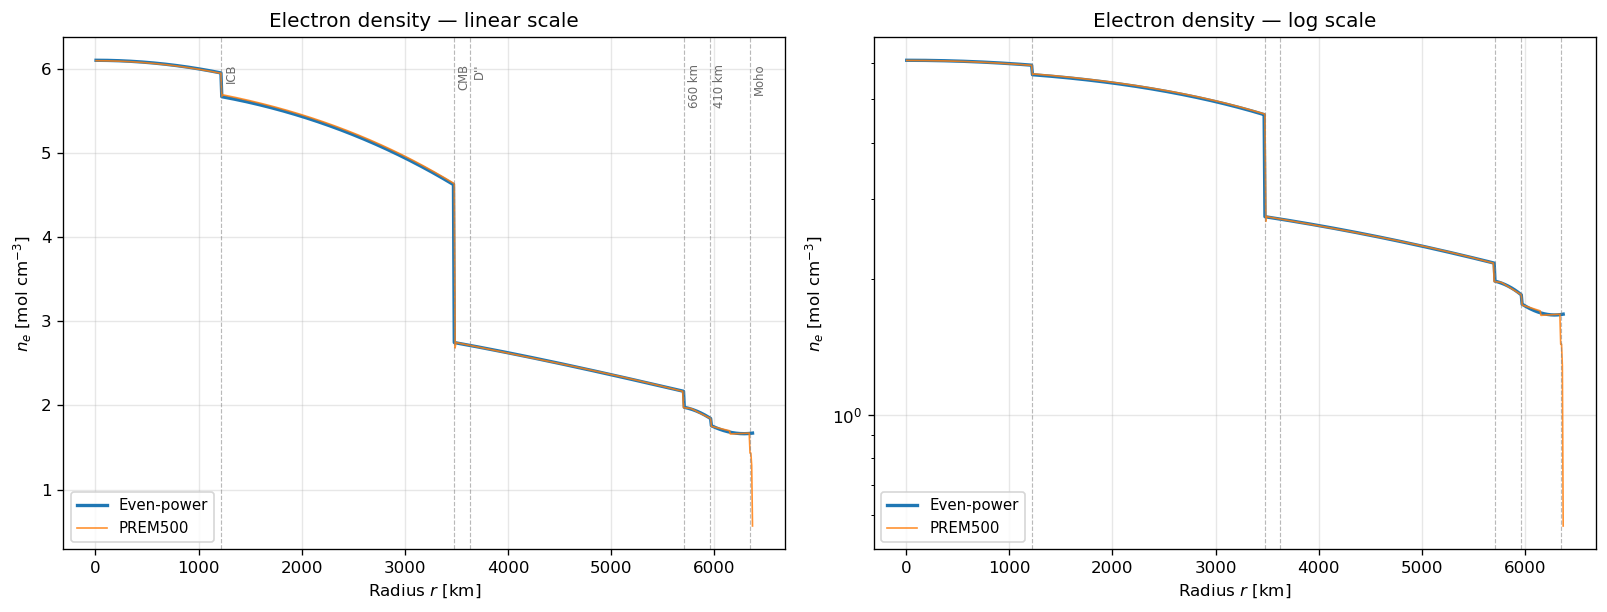

v:\output\analysis\earth\eg1_fig31_density_radial.png
Core n_e (even-power) : 6.099 mol/cm³
Core n_e (PREM)    : 6.094 mol/cm³
CMB  n_e (even-power) : 2.746 mol/cm³
CMB  n_e (PREM)    : 4.633 mol/cm³
Surf n_e (even-power) : 1.6687 mol/cm³
Surf n_e (PREM)    : 1.2844 mol/cm³


In [4]:
r_grid  = torch.linspace(0.001, 1.0, 800, dtype=ctx.dtype, device=ctx.device)
eta0    = torch.tensor(0.0, dtype=ctx.dtype, device=ctx.device)
ne_even = earth_even.density_x_eta(r_grid, eta0).cpu().numpy()
ne_prem = earth_prem.density_x_eta(r_grid, eta0).cpu().numpy()
r_km    = r_grid.cpu().numpy() * R_E_KM

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
for ax, yscale in zip(axes, ['linear', 'log']):
    ax.plot(r_km, ne_even, lw=2.0, color='#1f77b4', label='Even-power')
    ax.plot(r_km, ne_prem, lw=1.0, color='#ff7f0e', alpha=0.85, label='PREM')
    for d_km, dlabel in zip(DISC_KM, DISC_LABELS):
        ax.axvline(d_km, color='gray', ls='--', lw=0.7, alpha=0.55)
        if yscale == 'linear':
            ylim = ax.get_ylim()
            ax.text(d_km + 30, ylim[1] * 0.95, dlabel,
                    fontsize=7, rotation=90, va='top', color='dimgray')
    ax.set_xlabel(r'Radius $r$ [km]')
    ax.set_ylabel(r'$n_e$ [mol cm$^{-3}$]')
    ax.set_yscale(yscale)
    ax.legend(fontsize=9)

axes[0].set_title('Electron density — linear scale')
axes[1].set_title('Electron density — log scale')
fig.tight_layout()
save_and_show('eg1_fig31_density_radial.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f'Core n_e (even-power) : {ne_even[0]:.3f} mol/cm³')
print(f'Core n_e (PREM)    : {ne_prem[0]:.3f} mol/cm³')
idx_cmb = np.argmin(np.abs(r_km - CMB_KM))
print(f'CMB  n_e (even-power) : {ne_even[idx_cmb]:.3f} mol/cm³')
print(f'CMB  n_e (PREM)    : {ne_prem[idx_cmb]:.3f} mol/cm³')
idx_surf = np.argmin(np.abs(r_km - R_E_KM * 0.999))
print(f'Surf n_e (even-power) : {ne_even[idx_surf]:.4f} mol/cm³')
print(f'Surf n_e (PREM)    : {ne_prem[idx_surf]:.4f} mol/cm³')

### 3.2 Shell Boundary Structure

Each density model discretises the Earth into shells with outer boundary radii $\{r_j\}$. The even-power model uses a coarse shell grid (smooth polynomial within each shell); PREM uses 491 shells to reproduce every tabulated PREM discontinuity. The shell density near the major boundaries (ICB, CMB) determines the accuracy of the Earth matter-regeneration calculation.

**Expected results:** 
- The PREM shell grid has near-uniform spacing of $\sim 12$–$14$ km throughout.
- The even-power grid has a handful of wide shells with boundaries chosen to capture the main density jumps.

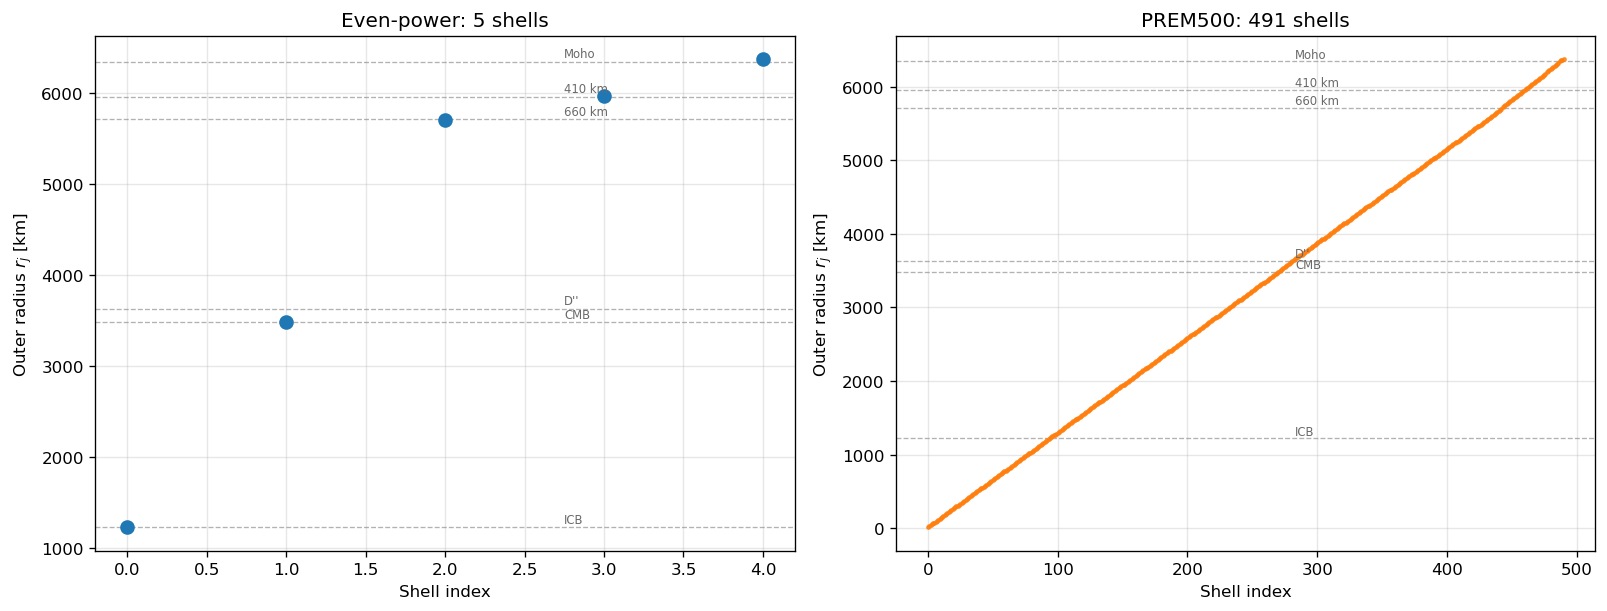

v:\output\analysis\earth\eg1_fig32_shells.png
Even-power | n_shells=  5 | width range [268, 2255] km
PREM    | n_shells=491 | width range [3.0, 18.5] km


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

axes[0].scatter(range(len(rj_even_km)), rj_even_km, s=60, color='#1f77b4', zorder=3)
axes[0].set_title(f'Even-power: {len(rj_even_km)} shells')

axes[1].scatter(range(len(rj_prem_km)), rj_prem_km, s=4, color='#ff7f0e', alpha=0.7, zorder=3)
axes[1].set_title(f'PREM: {len(rj_prem_km)} shells')

for ax in axes:
    for d_km, dlabel in zip(DISC_KM, DISC_LABELS):
        ax.axhline(d_km, color='gray', ls='--', lw=0.8, alpha=0.6)
        ax.text(ax.get_xlim()[1] * 0.55 if ax == axes[1] else len(rj_even_km) * 0.55,
                d_km + 50, dlabel, fontsize=7, color='dimgray')
    ax.set_xlabel('Shell index')
    ax.set_ylabel('Outer radius $r_j$ [km]')

fig.tight_layout()
save_and_show('eg1_fig32_shells.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

widths_even = np.diff(np.concatenate([[0.0], rj_even_km]))
widths_prem = np.diff(np.concatenate([[0.0], rj_prem_km]))
print(f'Even-power | n_shells={len(rj_even_km):3d} | width range [{widths_even.min():.0f}, {widths_even.max():.0f}] km')
print(f'PREM    | n_shells={len(rj_prem_km):3d} | width range [{widths_prem.min():.1f}, {widths_prem.max():.1f}] km')

### 3.3 Density Residuals: PREM − Even-Power

The difference $\Delta n_e(r) = n_e^{\rm PREM} - n_e^{\rm even}$ quantifies how much the smooth polynomial model deviates from the tabulated PREM at each radius. Large residuals near the ICB and CMB reflect the difficulty of polynomial approximation near sharp discontinuities.

**Expected results:**
- Peak absolute residuals at the ICB and CMB ($|\Delta n_e| \sim 0.1$–$0.5$ mol/cm³).
- Relative residuals $|\Delta n_e/n_e|$ can exceed 10% near discontinuities but are $< 2\%$ over most of the mantle.

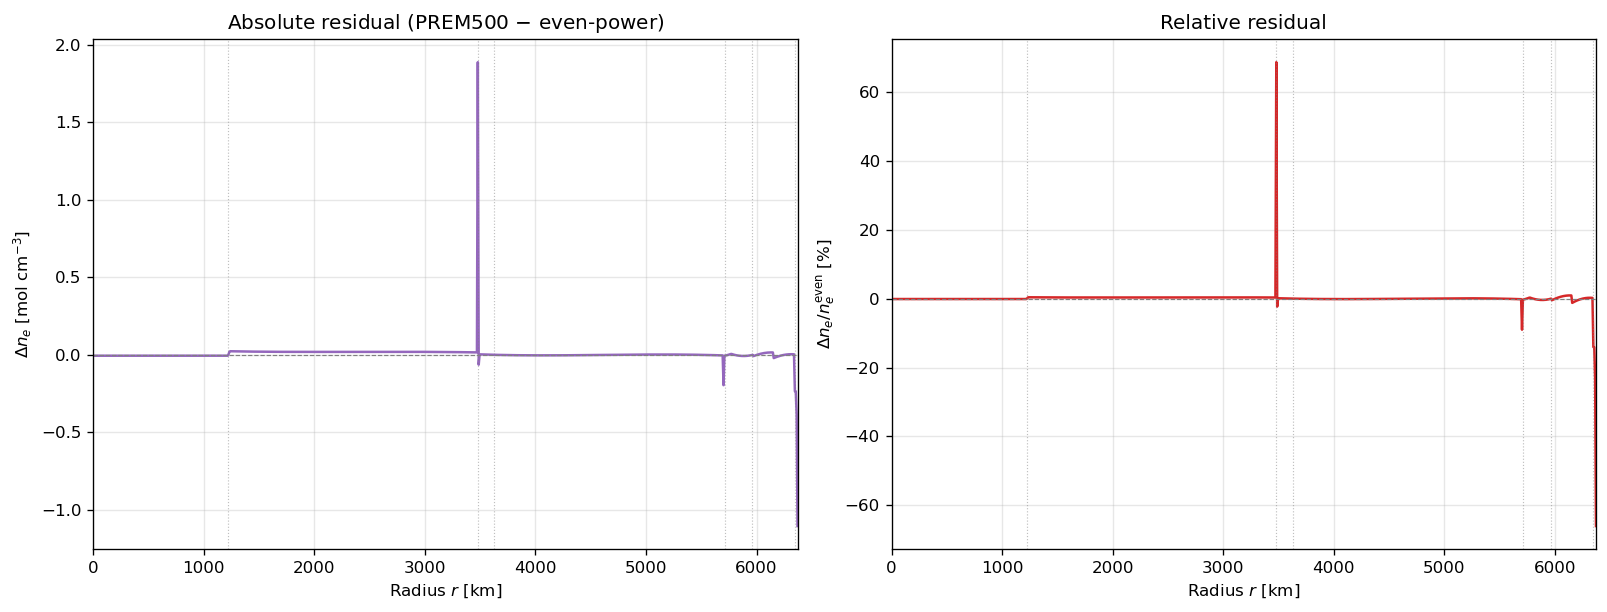

v:\output\analysis\earth\eg1_fig33_residuals.png
Max |Δn_e|         : 1.888 mol/cm³
Max |Δn_e/n_e|     : 68.7 %
RMS Δn_e           : 0.0806 mol/cm³
Mean |Δn_e/n_e|    : 0.46 %


In [6]:
delta_ne  = ne_prem - ne_even
rel_delta = delta_ne / np.maximum(np.abs(ne_even), 1e-6)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
axes[0].plot(r_km, delta_ne, color='#9467bd', lw=1.5)
axes[0].axhline(0, color='gray', lw=0.7, ls='--')
axes[0].set_ylabel(r'$\Delta n_e$ [mol cm$^{-3}$]')
axes[0].set_title('Absolute residual (PREM $-$ even-power)')

axes[1].plot(r_km, rel_delta * 100, color='#d62728', lw=1.5)
axes[1].axhline(0, color='gray', lw=0.7, ls='--')
axes[1].set_ylabel(r'$\Delta n_e / n_e^{\rm even}$ [%]')
axes[1].set_title('Relative residual')

for ax in axes:
    for d_km, dlabel in zip(DISC_KM, DISC_LABELS):
        ax.axvline(d_km, color='gray', ls=':', lw=0.7, alpha=0.5)
    ax.set_xlabel(r'Radius $r$ [km]')
    ax.set_xlim(0, R_E_KM)

fig.tight_layout()
save_and_show('eg1_fig33_residuals.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f'Max |Δn_e|         : {np.max(np.abs(delta_ne)):.3f} mol/cm³')
print(f'Max |Δn_e/n_e|     : {np.max(np.abs(rel_delta)) * 100:.1f} %')
print(f'RMS Δn_e           : {np.sqrt(np.mean(delta_ne**2)):.4f} mol/cm³')
print(f'Mean |Δn_e/n_e|    : {np.mean(np.abs(rel_delta)) * 100:.2f} %')

### 3.4 Matter Potential $V_{\rm CC}(r)$

The MSW matter potential $V_{\rm CC}(r) = \sqrt{2}\,G_F\,n_e(r)$ is the quantity that enters the oscillation Hamiltonian directly. Showing it alongside the reference oscillation scales $\Delta m^2/(2E)$ for atmospheric neutrinos at representative energies makes clear when the Earth matter effect is important.

The resonance condition $V_{\rm CC} = \cos 2\theta_{13}\,\Delta m^2_{32}/(2E)$ is met near the Earth core for atmospheric neutrinos at $E \sim 3$–$10$ GeV (atmospheric MSW resonance).

**Expected results:**
- $V_{\rm CC}$ at the Earth core ($n_e \approx 5$ mol/cm³): $\sim 3.8 \times 10^{-13}$ eV.
- The 3-GeV resonance line falls within the core/lower-mantle region.
- Below $\sim 1$ GeV, $\Delta m^2/2E > V_{\rm CC}$ everywhere: no Earth MSW resonance.

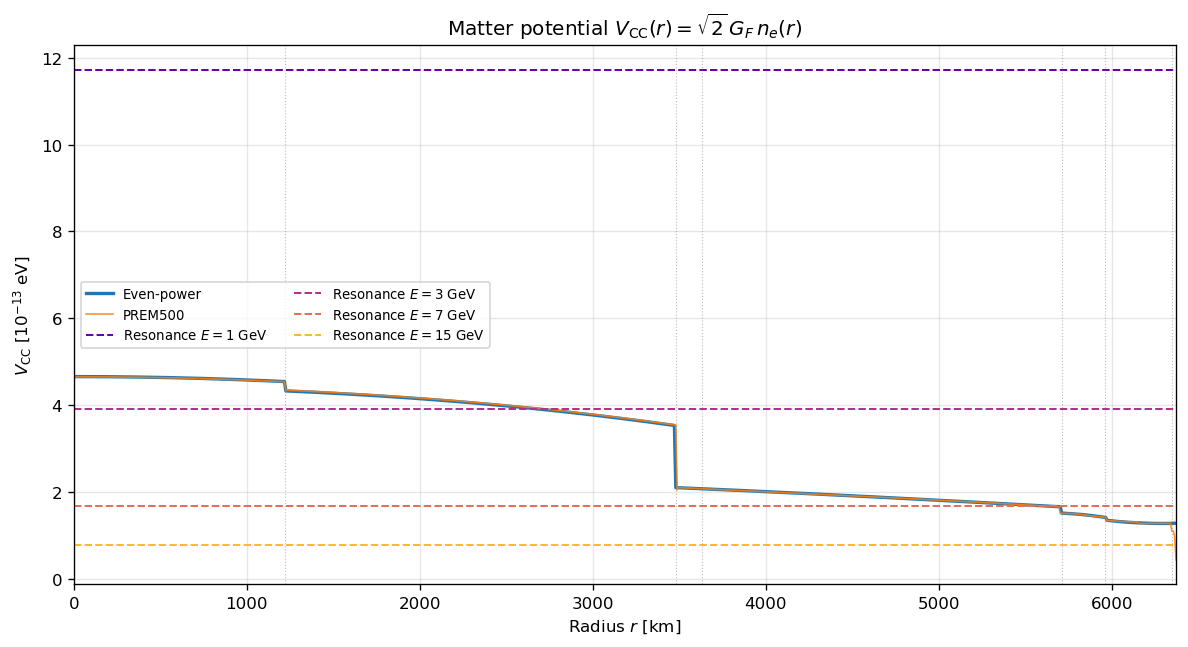

v:\output\analysis\earth\eg1_fig34_vmat.png
V_CC at Earth core (even-power) : 4.655 x10⁻¹³ eV
V_CC at Earth core (PREM)    : 4.651 x10⁻¹³ eV
MSW resonance conditions:
  E=  1.0 GeV -> V_res=11.7298e-13 eV -> r_res(PREM)~6 km
  E=  3.0 GeV -> V_res=3.9099e-13 eV -> r_res(PREM)~2715 km
  E=  7.0 GeV -> V_res=1.6757e-13 eV -> r_res(PREM)~5598 km
  E= 15.0 GeV -> V_res=0.7820e-13 eV -> r_res(PREM)~6363 km


In [7]:
# V_CC in units of 1e-13 eV for readability
VMAT_SCALE = 1e-13  # eV
vmat_even  = ne_even * VMAT_CONV_EV / VMAT_SCALE
vmat_prem  = ne_prem * VMAT_CONV_EV / VMAT_SCALE

# Reference: Δm²₃₂/(2E) for atmospheric neutrinos at several energies
DM32_EV2   = 2.455e-3   # eV², NuFIT 5.2 NO
COS2TH13   = math.cos(2 * math.radians(8.57))  # cos(2θ₁₃)
REF_E_GEV  = [1.0, 3.0, 7.0, 15.0]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(r_km, vmat_even, lw=2.0, color='#1f77b4', label='Even-power')
ax.plot(r_km, vmat_prem, lw=1.0, color='#ff7f0e', alpha=0.85, label='PREM')

# Resonance lines: V_CC = cos(2θ₁₃) * Δm²₃₂ / 2E
res_colors = plt.cm.plasma(np.linspace(0.2, 0.85, len(REF_E_GEV)))
for E_GeV, col in zip(REF_E_GEV, res_colors):
    E_eV   = E_GeV * 1e9
    v_res  = COS2TH13 * DM32_EV2 / (2.0 * E_eV)  # eV
    v_res_scaled = v_res / VMAT_SCALE
    ax.axhline(v_res_scaled, color=col, ls='--', lw=1.2,
               label=rf'Resonance $E={E_GeV:.0f}$ GeV')

for d_km, dlabel in zip(DISC_KM, DISC_LABELS):
    ax.axvline(d_km, color='gray', ls=':', lw=0.7, alpha=0.5)

ax.set_xlabel(r'Radius $r$ [km]')
ax.set_ylabel(r'$V_{\rm CC}$ [$10^{-13}$ eV]')
ax.set_title(r'Matter potential $V_{\rm CC}(r) = \sqrt{2}\,G_F\,n_e(r)$')
ax.set_xlim(0, R_E_KM)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
save_and_show('eg1_fig34_vmat.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f'V_CC at Earth core (even-power) : {vmat_even[0]:.3f} x10⁻¹³ eV')
print(f'V_CC at Earth core (PREM)    : {vmat_prem[0]:.3f} x10⁻¹³ eV')
print(f'MSW resonance conditions:')
for E_GeV in REF_E_GEV:
    v_res = COS2TH13 * DM32_EV2 / (2.0 * E_GeV * 1e9) / VMAT_SCALE
    r_res = r_km[np.argmin(np.abs(vmat_prem - v_res))]
    print(f'  E={E_GeV:5.1f} GeV -> V_res={v_res:.4f}e-13 eV -> r_res(PREM)~{r_res:.0f} km')

## 4. Earth Layer Anatomy

### 4.1 Layer Structure Diagram

A geophysical summary: each layer shown as a horizontal bar proportional to its thickness, with the average PREM electron density and the dominant mineralogy. This is the primary reference for interpreting which Earth regions contribute to the matter-regeneration effect at different nadir angles.

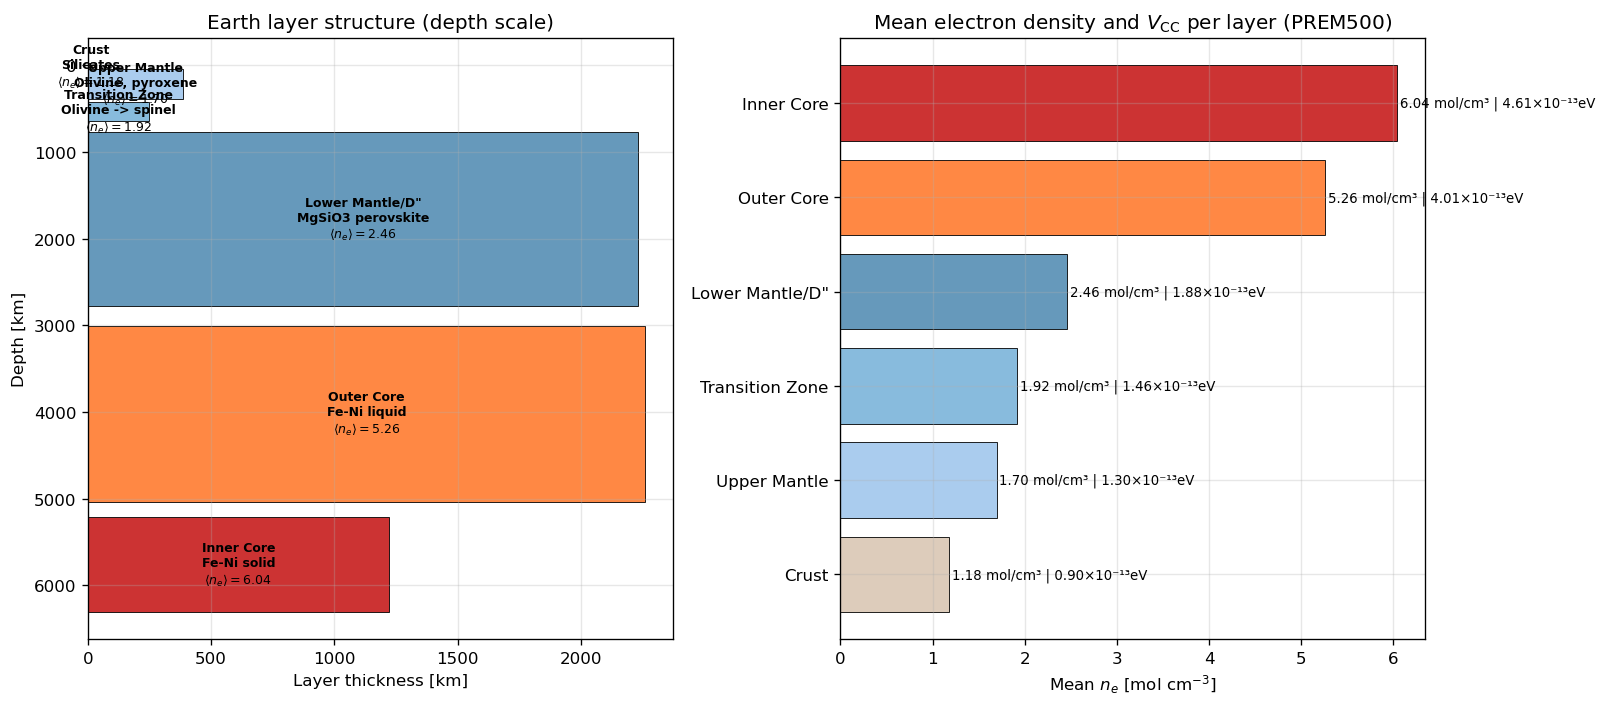

v:\output\analysis\earth\eg1_fig41_layer_anatomy.png
Layer summary (PREM):
Layer                  |     r_in |    r_out |    thick |     <ne> |   <V> /1e-13eV
--------------------------------------------------------------------------------
Inner Core             |     0.0  |  1221.5  |  1221.5  |   6.044  |         4.613
Outer Core             |  1221.5  |  3480.0  |  2258.5  |   5.257  |         4.012
Lower Mantle/D"        |  3480.0  |  5711.0  |  2231.0  |   2.464  |         1.881
Transition Zone        |  5711.0  |  5961.0  |   250.0  |   1.919  |         1.465
Upper Mantle           |  5961.0  |  6346.6  |   385.6  |   1.697  |         1.295
Crust                  |  6346.6  |  6371.0  |    24.4  |   1.179  |         0.900


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.0))

# Horizontal bar chart: depth profile
ax = axes[0]
for name, r_in, r_out, color, comp in LAYERS:
    thickness = r_out - r_in
    depth_top = R_E_KM - r_out
    ax.barh(depth_top + thickness / 2, thickness, height=thickness * 0.9,
            color=color, edgecolor='black', lw=0.5, align='center')
    # Mean n_e in this layer (PREM)
    mask = (r_km >= r_in) & (r_km <= r_out)
    ne_mean = ne_prem[mask].mean() if mask.sum() > 0 else 0.0
    ax.text(thickness * 0.5, depth_top + thickness / 2,
            f'{name}\n{comp}\n$\\langle n_e\\rangle={ne_mean:.2f}$',
            ha='center', va='center', fontsize=7.5, fontweight='bold')

ax.set_xlabel('Layer thickness [km]')
ax.set_ylabel('Depth [km]')
ax.invert_yaxis()
ax.set_title('Earth layer structure (depth scale)')

# Radial bar chart: radius profile
ax = axes[1]
for name, r_in, r_out, color, comp in LAYERS:
    mask = (r_km >= r_in) & (r_km <= r_out)
    ne_mean = ne_prem[mask].mean() if mask.sum() > 0 else 0.0
    vmat_mean = ne_mean * VMAT_CONV_EV / VMAT_SCALE
    ax.barh(name, ne_mean, color=color, edgecolor='black', lw=0.5)
    ax.text(ne_mean + 0.03, name, f'{ne_mean:.2f} mol/cm³ | {vmat_mean:.2f}×10⁻¹³eV',
            va='center', fontsize=8)

ax.set_xlabel(r'Mean $n_e$ [mol cm$^{-3}$]')
ax.set_title(r'Mean electron density and $V_{\rm CC}$ per layer (PREM)')
ax.invert_yaxis()

fig.tight_layout()
save_and_show('eg1_fig41_layer_anatomy.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f'Layer summary (PREM):')
print(f'{"Layer":<22} | {"r_in":>8} | {"r_out":>8} | {"thick":>8} | {"<ne>":>8} | {"<V> /1e-13eV":>14}')
print('-' * 80)
for name, r_in, r_out, _, _ in LAYERS:
    mask = (r_km >= r_in) & (r_km <= r_out)
    ne_m = ne_prem[mask].mean() if mask.sum() > 0 else 0.0
    vmat_m = ne_m * VMAT_CONV_EV / VMAT_SCALE
    print(f'{name:<22} | {r_in:>7.1f}  | {r_out:>7.1f}  | {r_out-r_in:>7.1f}  | {ne_m:>7.3f}  | {vmat_m:>13.3f}')

### 4.2 Per-Layer Density Zoom

Each geophysical layer is shown in its own panel with a zoomed x-axis. This reveals the fine structure of $n_e(r)$ within each region: the gradient within the outer core, the jump at the 660-km discontinuity, and the near-constant crust density. Both models are overlaid.

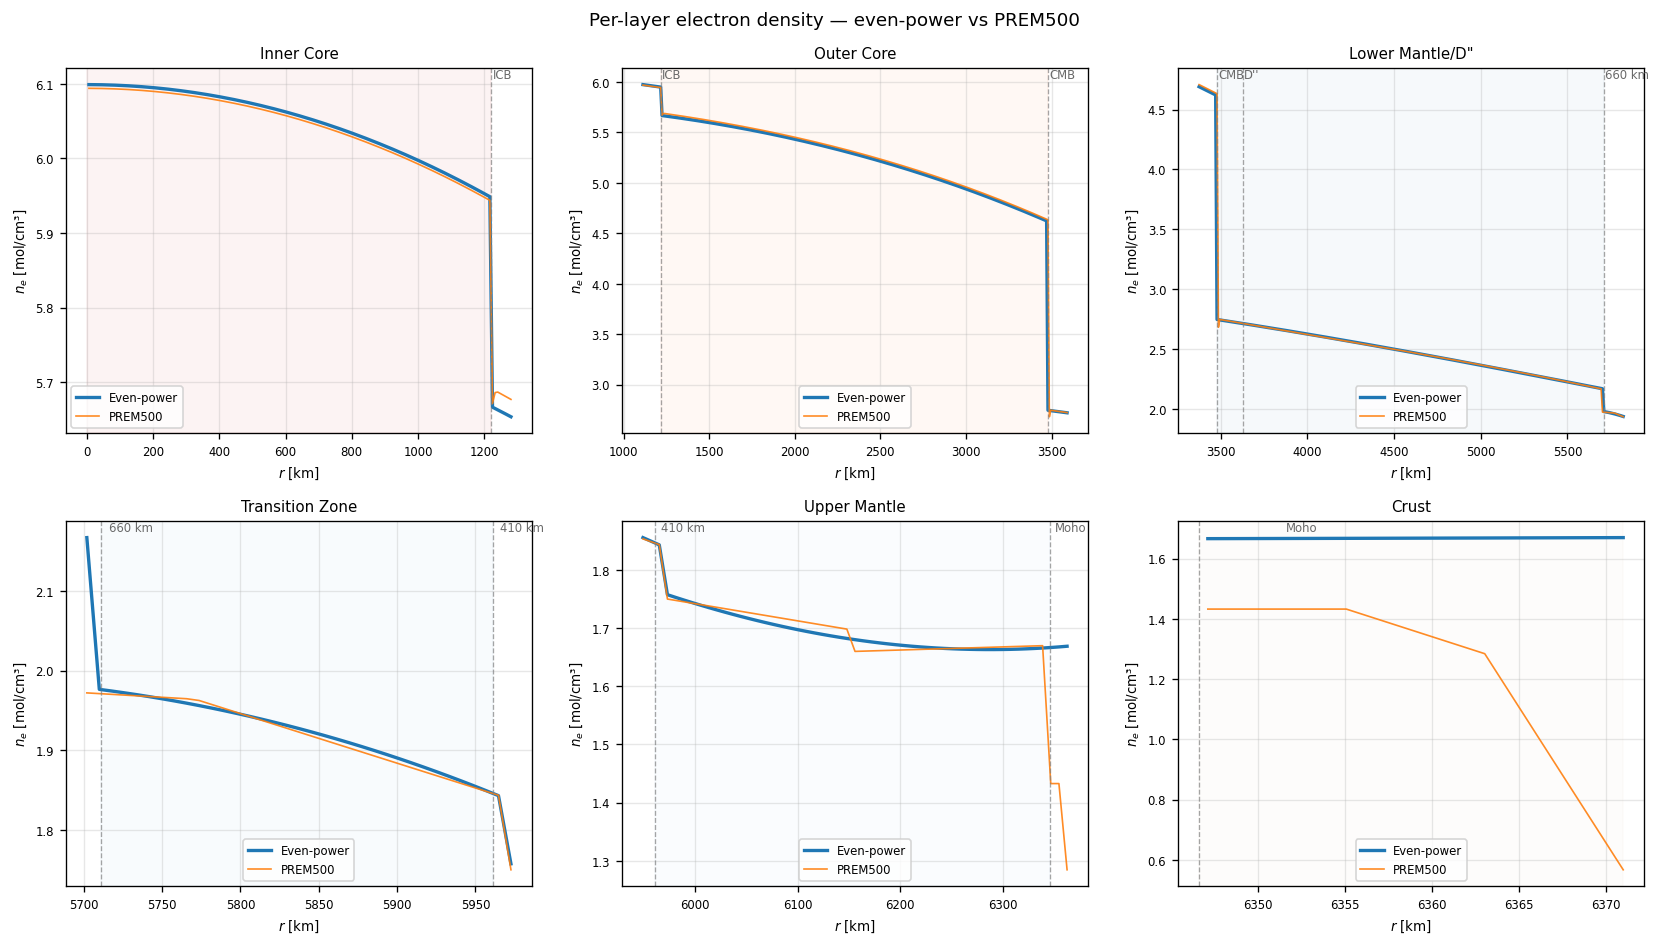

v:\output\analysis\earth\eg1_fig42_layer_zoom.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8.0))
axes_flat = axes.ravel()

for ax, (name, r_in, r_out, color, comp) in zip(axes_flat, LAYERS):
    margin = (r_out - r_in) * 0.05
    r_lo = max(0, r_in - margin)
    r_hi = min(R_E_KM, r_out + margin)
    mask = (r_km >= r_lo) & (r_km <= r_hi)

    ax.plot(r_km[mask], ne_even[mask], lw=2.0, color='#1f77b4', label='Even-power')
    ax.plot(r_km[mask], ne_prem[mask], lw=1.0, color='#ff7f0e', alpha=0.9, label='PREM')
    ax.axvspan(r_in, r_out, alpha=0.06, color=color)

    for d_km, dlabel in zip(DISC_KM, DISC_LABELS):
        if r_lo < d_km < r_hi:
            ax.axvline(d_km, color='gray', ls='--', lw=0.8, alpha=0.7)
            ax.text(d_km + 5, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1,
                    dlabel, fontsize=7, color='dimgray', va='top')

    ax.set_title(f'{name}', fontsize=9)
    ax.set_xlabel(r'$r$ [km]', fontsize=8)
    ax.set_ylabel(r'$n_e$ [mol/cm³]', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

fig.suptitle('Per-layer electron density — even-power vs PREM', fontsize=11)
fig.tight_layout()
save_and_show('eg1_fig42_layer_zoom.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

## 5. Chord Geometry

### 5.1 Critical Nadir Angles

Each geophysical boundary at radius $r_j$ defines a **critical nadir angle** $\eta_j = \arccos(r_j / R_\oplus)$. Only trajectories with $\eta < \eta_j$ cross into the layer below that boundary. This table and plot are the primary guide for selecting representative nadir angles in oscillation analyses.

**Expected results:**
- ICB ($r = 1221.5$ km): $\eta_{\rm IC} \approx 79°$ — only the most vertical neutrinos reach the inner core.
- CMB ($r = 3480$ km): $\eta_{\rm OC} \approx 57°$ — a substantial fraction of upward-going neutrinos cross the outer core.
- Moho ($r = 6346.6$ km): $\eta_{\rm Moho} \approx 4°$ — only near-horizontal neutrinos are confined to the crust.

Boundary                       |   r [km] |  eta_c [deg] | Access condition
---------------------------------------------------------------------------
ICB (IC/OC)                    |   1221.5 |      78.95°  | eta < 78.9°
CMB (OC/Mantle)                |   3480.0 |      56.89°  | eta < 56.9°
D'' base                       |   3630.0 |      55.27°  | eta < 55.3°
660-km discontinuity           |   5711.0 |      26.31°  | eta < 26.3°
410-km discontinuity           |   5961.0 |      20.67°  | eta < 20.7°
Moho (Mantle/Crust)            |   6346.6 |       5.02°  | eta < 5.0°


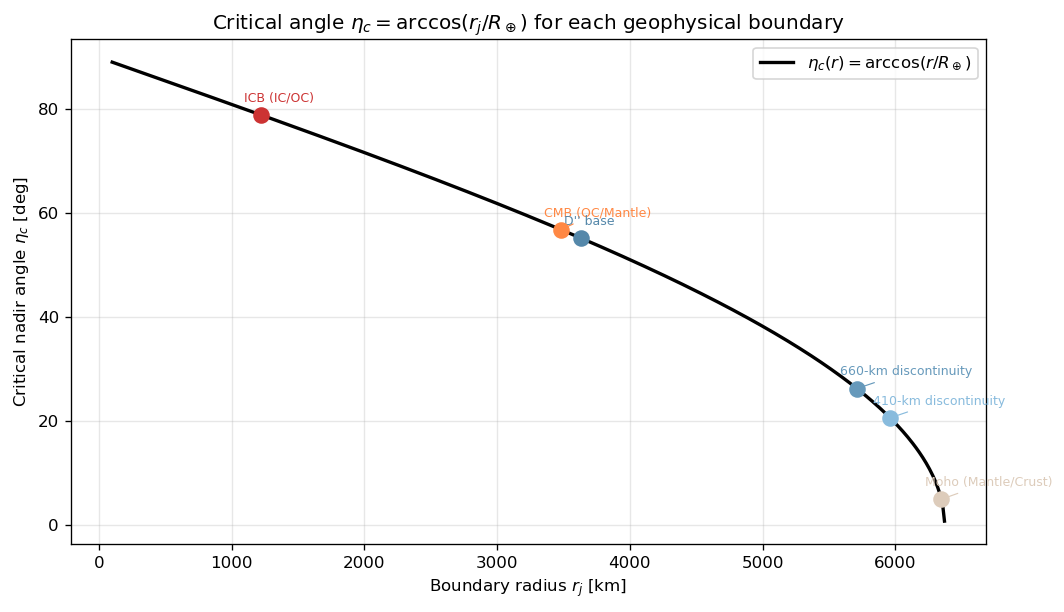

v:\output\analysis\earth\eg1_fig51_critical_angles.png


In [10]:
BOUNDARIES = [
    ('ICB (IC/OC)',            ICB_KM),
    ('CMB (OC/Mantle)',        CMB_KM),
    ("D'' base",               DPP_KM),
    ('660-km discontinuity',   D660_KM),
    ('410-km discontinuity',   D410_KM),
    ('Moho (Mantle/Crust)',    MOHO_KM),
]
eta_crit_deg = {name: math.degrees(math.acos(r / R_E_KM)) for name, r in BOUNDARIES}

print(f'{"Boundary":<30} | {"r [km]":>8} | {"eta_c [deg]":>12} | Access condition')
print('-' * 75)
for (name, r_km_b) in BOUNDARIES:
    eta_c = eta_crit_deg[name]
    print(f'{name:<30} | {r_km_b:>8.1f} | {eta_c:>10.2f}°  | eta < {eta_c:.1f}°')

# Plot: eta_c as function of layer radius
r_scan = np.linspace(100, R_E_KM * 0.9999, 500)
eta_scan = np.degrees(np.arccos(r_scan / R_E_KM))

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.plot(r_scan, eta_scan, 'k-', lw=2, label=r'$\eta_c(r) = \arccos(r/R_\oplus)$')

colors_b = ['#CC3333', '#FF8844', '#5588AA', '#6699BB', '#88BBDD', '#DDCCBB']
for (name, r_km_b), col in zip(BOUNDARIES, colors_b):
    eta_c = eta_crit_deg[name]
    ax.scatter([r_km_b], [eta_c], s=80, color=col, zorder=5)
    ax.annotate(name, xy=(r_km_b, eta_c), xytext=(-10, 8),
                textcoords='offset points', fontsize=7.5, color=col,
                arrowprops=dict(arrowstyle='-', color=col, lw=0.7))

ax.set_xlabel(r'Boundary radius $r_j$ [km]')
ax.set_ylabel(r'Critical nadir angle $\eta_c$ [deg]')
ax.set_title(r'Critical angle $\eta_c = \arccos(r_j / R_\oplus)$ for each geophysical boundary')
ax.legend()
fig.tight_layout()
save_and_show('eg1_fig51_critical_angles.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

### 5.2 2D Chord Diagram

A cross-section of the Earth showing neutrino chord trajectories for several nadir angles. For a detector at the top of the Earth (0, $R_\oplus$), a neutrino arriving at nadir angle $\eta$ enters the Earth surface at $(\sin 2\eta,\,-\cos 2\eta)\,R_\oplus$ and reaches the detector at $(0, R_\oplus)$. The minimum radius along the chord is $r_{\min} = R_\oplus \sin\eta$, reached at the midpoint.

Layer boundaries are drawn as dashed circles. The diagram makes immediately clear which Earth layers each trajectory samples.

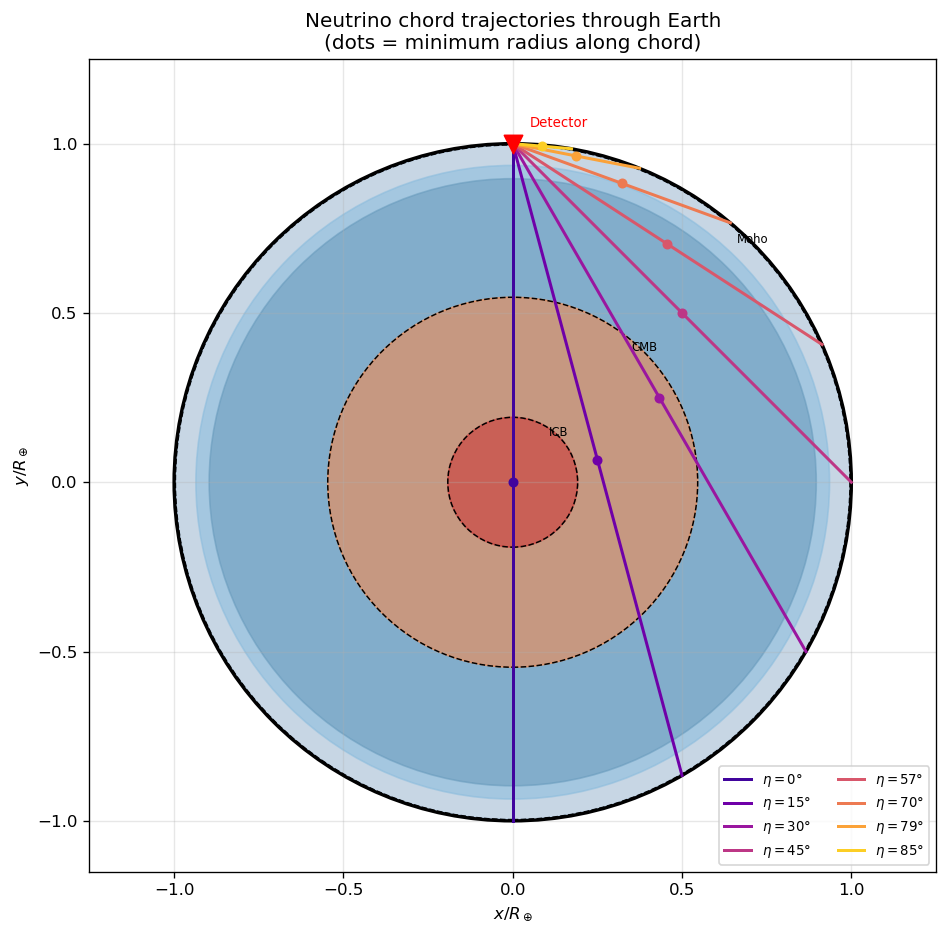

v:\output\analysis\earth\eg1_fig52_chord_diagram.png


In [11]:
ETA_CHORD_DEG = [0, 15, 30, 45, 57, 70, 79, 85]
chord_colors  = plt.cm.plasma(np.linspace(0.1, 0.9, len(ETA_CHORD_DEG)))

fig, ax = plt.subplots(figsize=(8, 9), facecolor='white')
ax.set_aspect('equal')

# Draw Earth layers (inner to outer so outer paints over inner)
for name, r_in, r_out, color, _ in reversed(LAYERS):
    circle = plt.Circle((0, 0), r_out / R_E_KM, color=color, alpha=0.55, zorder=1)
    ax.add_patch(circle)

# Boundary circles
for r_km_b, dlabel in [(ICB_KM, 'ICB'), (CMB_KM, 'CMB'), (MOHO_KM, 'Moho')]:
    circle = plt.Circle((0, 0), r_km_b / R_E_KM, fill=False,
                         edgecolor='black', lw=0.9, ls='--', zorder=2)
    ax.add_patch(circle)
    ax.text(r_km_b / R_E_KM * 0.71, r_km_b / R_E_KM * 0.71, dlabel,
            fontsize=7, ha='center', color='black')

# Earth surface
circle = plt.Circle((0, 0), 1.0, fill=False, edgecolor='black', lw=2, zorder=3)
ax.add_patch(circle)

# Detector
ax.scatter([0], [1.0], s=120, color='red', zorder=6, marker='v')
ax.annotate('Detector', xy=(0, 1.0), xytext=(0.05, 1.05), fontsize=8, color='red')

# Draw chords
for eta_deg, col in zip(ETA_CHORD_DEG, chord_colors):
    eta_rad = math.radians(eta_deg)
    # Entry point on opposite Earth surface
    x_entry = math.sin(2 * eta_rad)
    y_entry = -math.cos(2 * eta_rad)
    ax.plot([x_entry, 0], [y_entry, 1.0], color=col, lw=1.8, zorder=4,
            label=rf'$\eta={eta_deg}°$')
    # Mark minimum-radius midpoint
    x_mid = math.sin(eta_rad) * math.cos(eta_rad)
    y_mid = math.sin(eta_rad) ** 2
    ax.scatter([x_mid], [y_mid], s=25, color=col, zorder=5)

ax.set_xlim(-1.25, 1.25)
ax.set_ylim(-1.15, 1.25)
ax.set_xlabel(r'$x / R_\oplus$')
ax.set_ylabel(r'$y / R_\oplus$')
ax.set_title('Neutrino chord trajectories through Earth\n(dots = minimum radius along chord)')
ax.legend(fontsize=8, loc='lower right', ncol=2)
fig.tight_layout()
save_and_show('eg1_fig52_chord_diagram.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

### 5.3 Chord Length and Minimum Radius

The two most important geometric properties of a trajectory as functions of $\eta$:
- **Chord length** $L(\eta) = 2R_\oplus\cos\eta$ — controls the total matter phase accumulated.
- **Minimum radius** $r_{\min}(\eta) = R_\oplus\sin\eta$ — determines which Earth layers are probed.

The critical angles from §5.1 are marked as vertical reference lines.

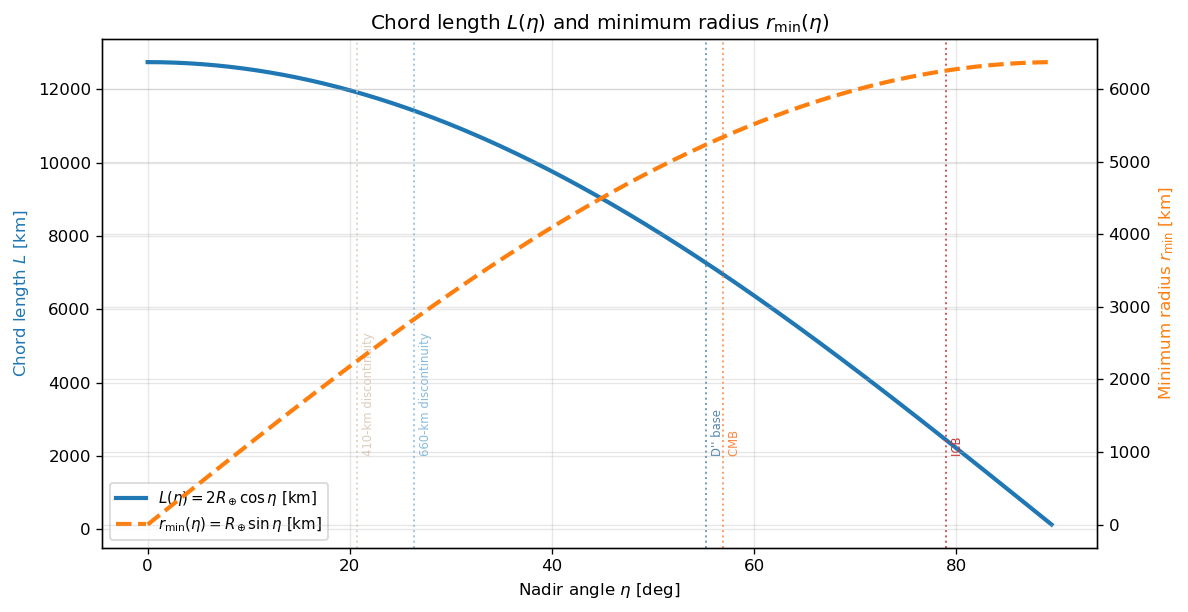

v:\output\analysis\earth\eg1_fig53_chord_length.png
 eta [deg] |       L [km] |   r_min [km] | Layer accessed
------------------------------------------------------------
         0° |      12742   |          0   | Inner Core
        15° |      12308   |       1649   | Outer Core
        30° |      11035   |       3185   | Outer Core
        45° |       9010   |       4505   | Lower Mantle/D"
        57° |       6940   |       5343   | Lower Mantle/D"
        70° |       4358   |       5987   | Upper Mantle
        79° |       2431   |       6254   | Upper Mantle
        85° |       1111   |       6347   | Crust


In [12]:
ETA_SCAN = np.linspace(0.0, math.pi / 2 - 0.01, 400)
L_km     = 2.0 * R_E_KM * np.cos(ETA_SCAN)
R_MIN_km = R_E_KM * np.sin(ETA_SCAN)

fig, ax1 = plt.subplots(figsize=(10, 5.2))
ax2 = ax1.twinx()

ax1.plot(np.degrees(ETA_SCAN), L_km, 'C0', lw=2.5, label=r'$L(\eta) = 2R_\oplus\cos\eta$ [km]')
ax2.plot(np.degrees(ETA_SCAN), R_MIN_km, 'C1', lw=2.5, ls='--',
         label=r'$r_{\min}(\eta) = R_\oplus\sin\eta$ [km]')

colors_b = ['#CC3333', '#FF8844', '#5588AA', '#88BBDD', '#DDCCBB']
for (name, r_km_b), col in zip(BOUNDARIES[:5], colors_b):
    eta_c = eta_crit_deg[name]
    ax1.axvline(eta_c, color=col, ls=':', lw=1.2, alpha=0.8)
    ax1.text(eta_c + 0.5, 2000, name.split('(')[0], fontsize=7, color=col, rotation=90, va='bottom')

ax1.set_xlabel(r'Nadir angle $\eta$ [deg]')
ax1.set_ylabel(r'Chord length $L$ [km]', color='C0')
ax2.set_ylabel(r'Minimum radius $r_{\min}$ [km]', color='C1')
ax1.set_title(r'Chord length $L(\eta)$ and minimum radius $r_{\min}(\eta)$')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
fig.tight_layout()
save_and_show('eg1_fig53_chord_length.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f'{"eta [deg]":>10} | {"L [km]":>12} | {"r_min [km]":>12} | Layer accessed')
print('-' * 60)
for eta_d in [0, 15, 30, 45, 57, 70, 79, 85]:
    eta_r = math.radians(eta_d)
    L_val = 2.0 * R_E_KM * math.cos(eta_r)
    rmin  = R_E_KM * math.sin(eta_r)
    layer = next((n for n, r_in, r_out, _, _ in LAYERS if r_in <= rmin < r_out), 'surface')
    print(f'{eta_d:>10}° | {L_val:>10.0f}   | {rmin:>10.0f}   | {layer}')

### 5.4 Electron Density Along the Chord

The actual density profile $n_e(x, \eta)$ seen by the neutrino along its trajectory, for the four representative nadir angles. The coordinate $x$ runs from the chord midpoint ($x = 0$, minimum radius) to the Earth surface ($x = \cos\eta$). Layer boundary crossings appear as density jumps. This is the input to the oscillation Hamiltonian integrator.

For symmetric Earth-crossing trajectories the density is symmetric about $x = 0$, so only the positive half is shown.

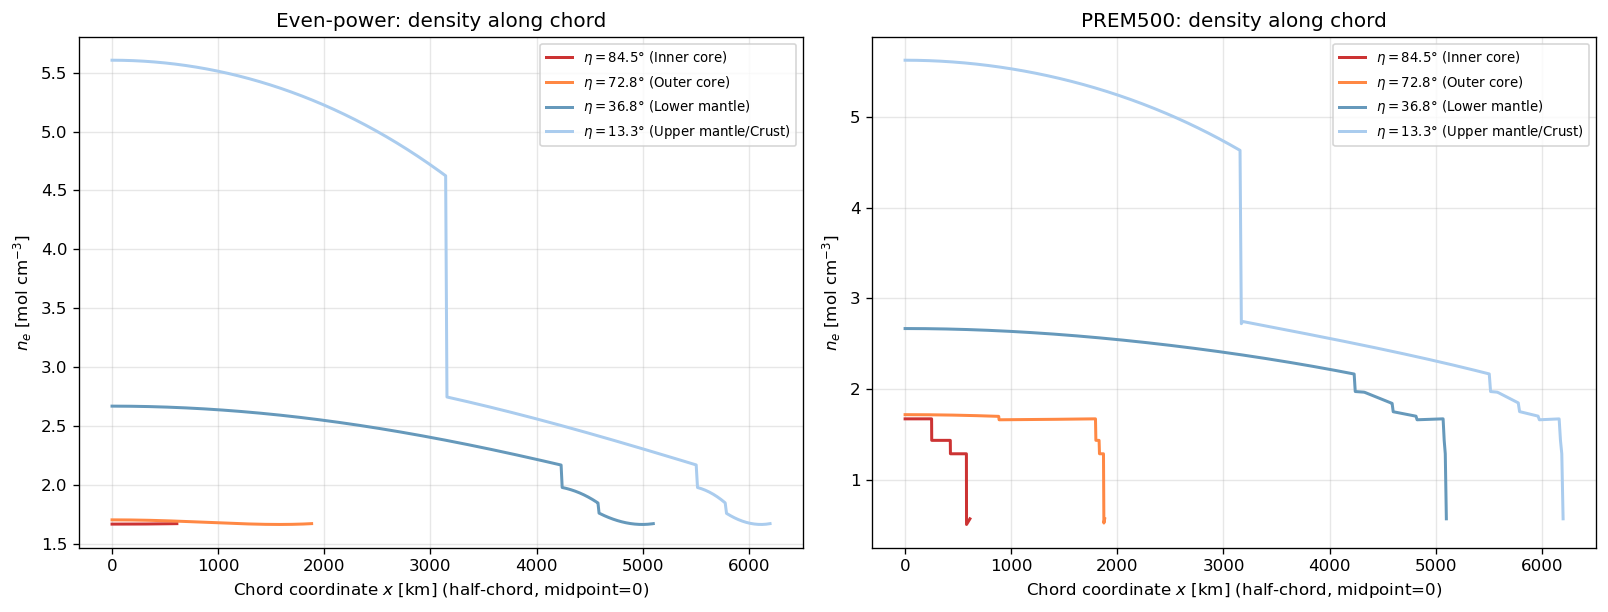

v:\output\analysis\earth\eg1_fig54_chord_profile.png


In [13]:
NAMED_ETAS = [
    (math.degrees(math.acos(ICB_KM * 0.5 / R_E_KM)),  '#CC3333', 'Inner core'),
    (math.degrees(math.acos((ICB_KM + CMB_KM) * 0.4 / R_E_KM)), '#FF8844', 'Outer core'),
    (math.degrees(math.acos(5100.0 / R_E_KM)),         '#6699BB', 'Lower mantle'),
    (math.degrees(math.acos(6200.0 / R_E_KM)),         '#AACCEE', 'Upper mantle/Crust'),
]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

for eta_deg, col, layer_name in NAMED_ETAS:
    eta_rad = math.radians(eta_deg)
    eta_t   = torch.tensor(eta_rad, dtype=ctx.dtype, device=ctx.device)
    x_max   = math.cos(eta_rad)
    x_traj  = torch.linspace(0.0, x_max, 500, dtype=ctx.dtype, device=ctx.device)
    label   = rf'$\eta={eta_deg:.1f}°$ ({layer_name})'

    for ax, earth_model, ne_ref in [
        (axes[0], earth_even, ne_even),
        (axes[1], earth_prem, ne_prem),
    ]:
        ne_traj = earth_model.density_x_eta(x_traj, eta_t).cpu().numpy()
        x_km    = x_traj.cpu().numpy() * R_E_KM
        ax.plot(x_km, ne_traj, color=col, lw=1.8, label=label)

for ax, title in zip(axes, ['Even-power', 'PREM']):
    ax.set_xlabel(r'Chord coordinate $x$ [km] (half-chord, midpoint=0)')
    ax.set_ylabel(r'$n_e$ [mol cm$^{-3}$]')
    ax.set_title(f'{title}: density along chord')
    ax.legend(fontsize=8)

fig.tight_layout()
save_and_show('eg1_fig54_chord_profile.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

## 6. Path Length and Column Density

### 6.1 Path Length per Layer vs $\eta$

For each nadir angle, the chord is sampled on a fine grid and each sample point is assigned to its geophysical layer (by radius). The path length in each layer is the total chord length within that layer.

The stacked bar chart shows how the chord decomposes by layer as $\eta$ varies from $0°$ (vertical, maximum inner-core crossing) to $90°$ (horizontal, no Earth crossing).

**Expected results:**
- At $\eta = 0$: chord = $2R_\oplus \approx 12742$ km — inner core + outer core + mantle.
- For $\eta > \eta_{\rm ICB} \approx 79°$: no inner-core contribution.
- For $\eta > \eta_{\rm CMB} \approx 57°$: no core contribution at all — chord is entirely mantle/crust.

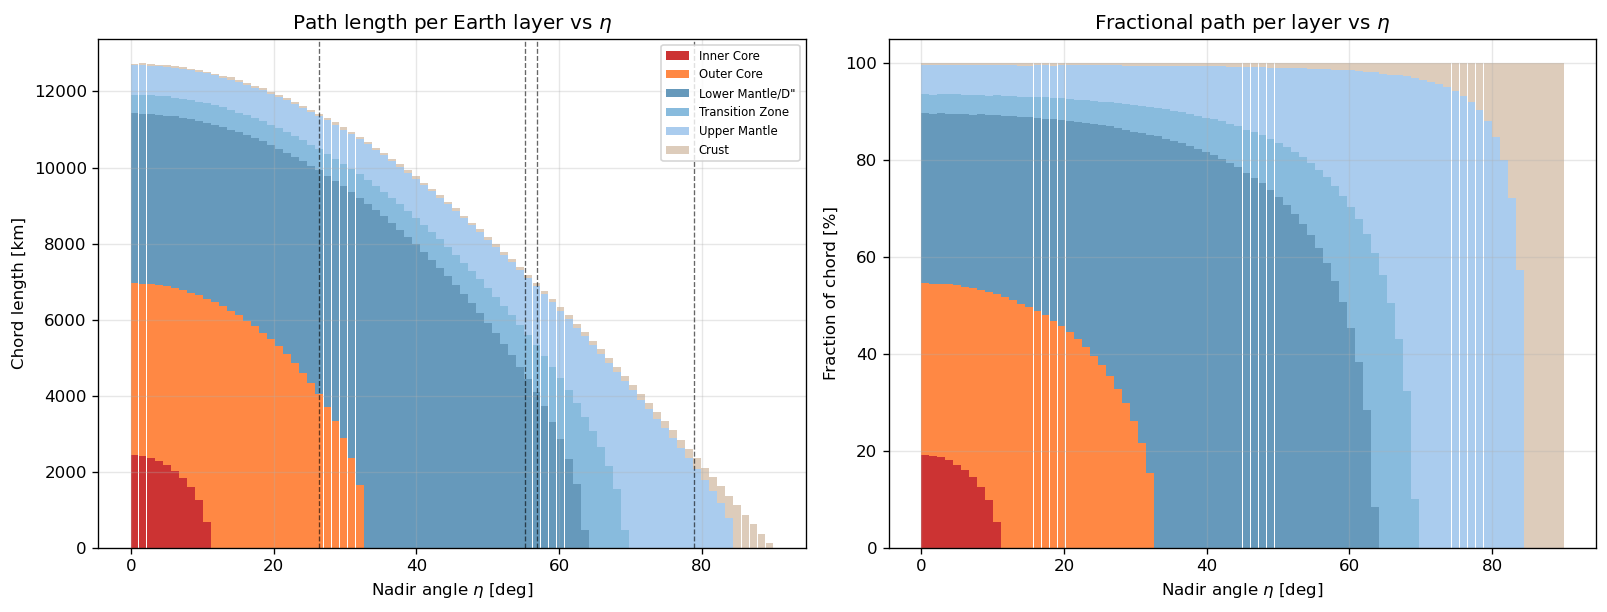

v:\output\analysis\earth\eg1_fig61_path_per_layer.png
Path lengths at selected eta values:
 eta [deg] |   L_total [km] |   IC [km] |   OC [km] |  Mantle [km]
-----------------------------------------------------------------
         0° |        12735   |    2435   |    4526   |       4462
        10° |        12573   |    1245   |    5394   |       4589
        11° |        12517   |     664   |    5889   |       4623
        20° |        11994   |       0   |    5487   |       5102
        21° |        11907   |       0   |    5292   |       5197
        30° |        11064   |       0   |    2888   |       6616
        31° |        10926   |       0   |    2362   |       7000
        39° |         9925   |       0   |       0   |       8166
        40° |         9766   |       0   |       0   |       7977
        41° |         9603   |       0   |       0   |       7777
        49° |         8373   |       0   |       0   |       6179
        50° |         8174   |       0   |       0

In [14]:
N_TRAJ = 2000
ETA_SCAN_DEG = np.linspace(0.5, 89.5, 80)

layer_names  = [l[0] for l in LAYERS]
layer_colors = [l[3] for l in LAYERS]
length_data  = {name: [] for name, *_ in LAYERS}

for eta_deg in ETA_SCAN_DEG:
    eta_rad  = math.radians(eta_deg)
    x_max    = math.cos(eta_rad)
    x_arr    = np.linspace(-x_max, x_max, N_TRAJ)
    r_arr    = np.sqrt(x_arr**2 + math.sin(eta_rad)**2) * R_E_KM
    dx_km    = 2.0 * x_max / (N_TRAJ - 1) * R_E_KM
    for name, r_in, r_out, _, _ in LAYERS:
        mask = (r_arr >= r_in) & (r_arr < r_out)
        length_data[name].append(mask.sum() * dx_km)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

# Stacked bar chart
bottom = np.zeros(len(ETA_SCAN_DEG))
for name, col in zip(layer_names, layer_colors):
    vals = np.array(length_data[name])
    axes[0].bar(ETA_SCAN_DEG, vals, bottom=bottom, width=1.1,
                color=col, edgecolor='none', label=name)
    bottom += vals

for (name_b, r_km_b) in BOUNDARIES[:4]:
    eta_c = eta_crit_deg[name_b]
    axes[0].axvline(eta_c, color='black', ls='--', lw=0.8, alpha=0.6)

axes[0].set_xlabel(r'Nadir angle $\eta$ [deg]')
axes[0].set_ylabel('Chord length [km]')
axes[0].set_title('Path length per Earth layer vs $\\eta$')
axes[0].legend(fontsize=7, loc='upper right')

# Fractional breakdown
total = np.array([sum(length_data[n][i] for n in layer_names) for i in range(len(ETA_SCAN_DEG))])
total = np.maximum(total, 1.0)  # avoid division by zero near eta=90
bottom = np.zeros(len(ETA_SCAN_DEG))
for name, col in zip(layer_names, layer_colors):
    frac = np.array(length_data[name]) / total
    axes[1].bar(ETA_SCAN_DEG, frac * 100, bottom=bottom * 100, width=1.1,
                color=col, edgecolor='none', label=name)
    bottom += frac

axes[1].set_xlabel(r'Nadir angle $\eta$ [deg]')
axes[1].set_ylabel('Fraction of chord [%]')
axes[1].set_title('Fractional path per layer vs $\\eta$')

fig.tight_layout()
save_and_show('eg1_fig61_path_per_layer.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f'Path lengths at selected eta values:')
print(f'{"eta [deg]":>10} | {"L_total [km]":>14} | {"IC [km]":>9} | {"OC [km]":>9} | {"Mantle [km]":>12}')
print('-' * 65)
for idx, eta_deg in enumerate(ETA_SCAN_DEG):
    if abs(eta_deg - round(eta_deg / 10) * 10) < 1.2:
        L_tot = sum(length_data[n][idx] for n in layer_names)
        L_IC  = length_data['Inner Core'][idx]
        L_OC  = length_data['Outer Core'][idx]
        L_M   = length_data['Lower Mantle/D"'][idx]
        print(f'{eta_deg:>10.0f}° | {L_tot:>12.0f}   | {L_IC:>7.0f}   | {L_OC:>7.0f}   | {L_M:>10.0f}')

### 6.2 Column Density and Matter Phase

The **column electron density**
$$\mathcal{N}(\eta) = \int_{-\cos\eta}^{\cos\eta} n_e(x,\eta)\,dx \times R_\oplus$$
is the total number of electrons per unit area along the chord (in mol/cm²). The associated **matter phase**
$$\phi_{\rm mat}(\eta) = \sqrt{2}\,G_F\,\mathcal{N}(\eta)$$
has units of eV·(length) = eV (when expressed in natural units via $\int V dl / (\hbar c)$).

The column density is the single number that best summarizes how much matter effect a neutrino at nadir angle $\eta$ accumulates. Comparing even-power vs PREM column densities shows how much the profile choice matters for the integrated oscillation effect.

**Expected results:**
- $\mathcal{N}(0) \approx 10^{10}$–$10^{11}$ mol/cm² for a vertical trajectory.
- The ratio $\mathcal{N}^{\rm PREM}/\mathcal{N}^{\rm even}$ deviates from 1 by $< 5\%$ for all $\eta$.

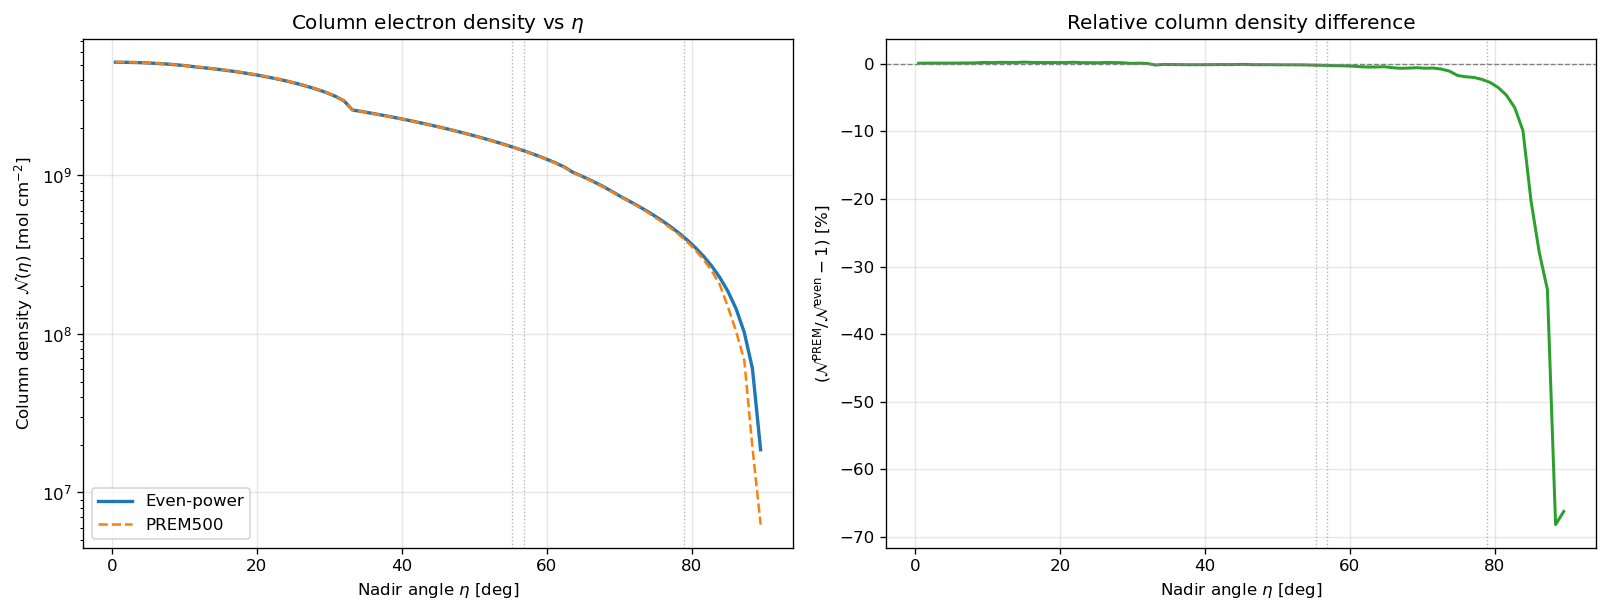

v:\output\analysis\earth\eg1_fig62_column_density.png
Column density and matter phase at selected angles:
   eta |   N_even [mol/cm²] |   N_prem [mol/cm²] |    Ratio |  phi_prem [eV]
---------------------------------------------------------------------------
    0° |        5.179e+09   |        5.184e+09   | 1.0010  |   3.9566e-04
   10° |        4.955e+09   |        4.966e+09   | 1.0021  |   3.7901e-04
   11° |        4.895e+09   |        4.904e+09   | 1.0018  |   3.7426e-04
   20° |        4.326e+09   |        4.335e+09   | 1.0020  |   3.3085e-04
   21° |        4.235e+09   |        4.243e+09   | 1.0019  |   3.2387e-04
   30° |        3.303e+09   |        3.305e+09   | 1.0007  |   2.5229e-04
   31° |        3.142e+09   |        3.145e+09   | 1.0011  |   2.4006e-04
   39° |        2.328e+09   |        2.325e+09   | 0.9988  |   1.7745e-04
   40° |        2.274e+09   |        2.271e+09   | 0.9988  |   1.7335e-04
   41° |        2.220e+09   |        2.217e+09   | 0.9989  |   1.6924e-04
 

In [15]:
R_E_CM = constant.R_E * 100.0  # cm

col_dens_even = []
col_dens_prem = []

for eta_deg in ETA_SCAN_DEG:
    eta_rad = math.radians(eta_deg)
    x_max   = math.cos(eta_rad)
    x_traj  = torch.linspace(-x_max, x_max, N_TRAJ, dtype=ctx.dtype, device=ctx.device)
    eta_t   = torch.tensor(eta_rad, dtype=ctx.dtype, device=ctx.device)

    ne_e = earth_even.density_x_eta(x_traj, eta_t)
    ne_p = earth_prem.density_x_eta(x_traj, eta_t)

    # Integrate: ∫ n_e dx [mol/cm³] * R_E [cm] = [mol/cm²]
    col_e = float(torch.trapz(ne_e, x_traj)) * R_E_CM
    col_p = float(torch.trapz(ne_p, x_traj)) * R_E_CM
    col_dens_even.append(col_e)
    col_dens_prem.append(col_p)

col_even = np.array(col_dens_even)
col_prem = np.array(col_dens_prem)

# Matter phase: phi = sqrt(2) G_F * N_A * col_density [mol/cm²] * (hbar*c [eV*cm])^-1 ... simplified
# In eV: phi [eV] = VMAT_CONV_EV * col_density [mol/cm²] (same conversion factor)
phi_even = col_even * VMAT_CONV_EV  # eV
phi_prem = col_prem * VMAT_CONV_EV

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

axes[0].semilogy(ETA_SCAN_DEG, col_even, 'C0', lw=2, label='Even-power')
axes[0].semilogy(ETA_SCAN_DEG, col_prem, 'C1', lw=1.5, ls='--', label='PREM')
axes[0].set_xlabel(r'Nadir angle $\eta$ [deg]')
axes[0].set_ylabel(r'Column density $\mathcal{N}(\eta)$ [mol cm$^{-2}$]')
axes[0].set_title('Column electron density vs $\\eta$')
axes[0].legend()

ratio = col_prem / np.maximum(col_even, 1e-30)
axes[1].plot(ETA_SCAN_DEG, (ratio - 1) * 100, 'C2', lw=1.8)
axes[1].axhline(0, color='gray', ls='--', lw=0.8)
axes[1].set_xlabel(r'Nadir angle $\eta$ [deg]')
axes[1].set_ylabel(r'$(\mathcal{N}^{\rm PREM}/\mathcal{N}^{\rm even} - 1)$ [%]')
axes[1].set_title('Relative column density difference')

for ax in axes:
    for (name_b, r_km_b) in BOUNDARIES[:3]:
        ax.axvline(eta_crit_deg[name_b], color='gray', ls=':', lw=0.8, alpha=0.6)

fig.tight_layout()
save_and_show('eg1_fig62_column_density.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f'Column density and matter phase at selected angles:')
print(f'{"eta":>6} | {"N_even [mol/cm²]":>18} | {"N_prem [mol/cm²]":>18} | {"Ratio":>8} | {"phi_prem [eV]":>14}')
print('-' * 75)
for idx, eta_deg in enumerate(ETA_SCAN_DEG):
    if abs(eta_deg - round(eta_deg / 10) * 10) < 1.2:
        print(f'{eta_deg:>5.0f}° | {col_even[idx]:>16.3e}   | {col_prem[idx]:>16.3e}   |'
              f' {ratio[idx]:>6.4f}  | {phi_prem[idx]:>12.4e}')

## 7. 2D Density Cross-Section

The electron density $n_e(x, y)$ over a 2D cross-section of the Earth (both models). Because the density is spherically symmetric, $n_e(x,y) = n_e(r)$ with $r = \sqrt{x^2 + y^2}$. The 2D map makes the layer structure, discontinuities, and density gradients immediately visible. Points outside the Earth ($r > R_\oplus$) are masked.

The right panel shows the absolute difference $\Delta n_e(x,y)$ between models, highlighting where the polynomial approximation deviates most from the PREM tabulation.

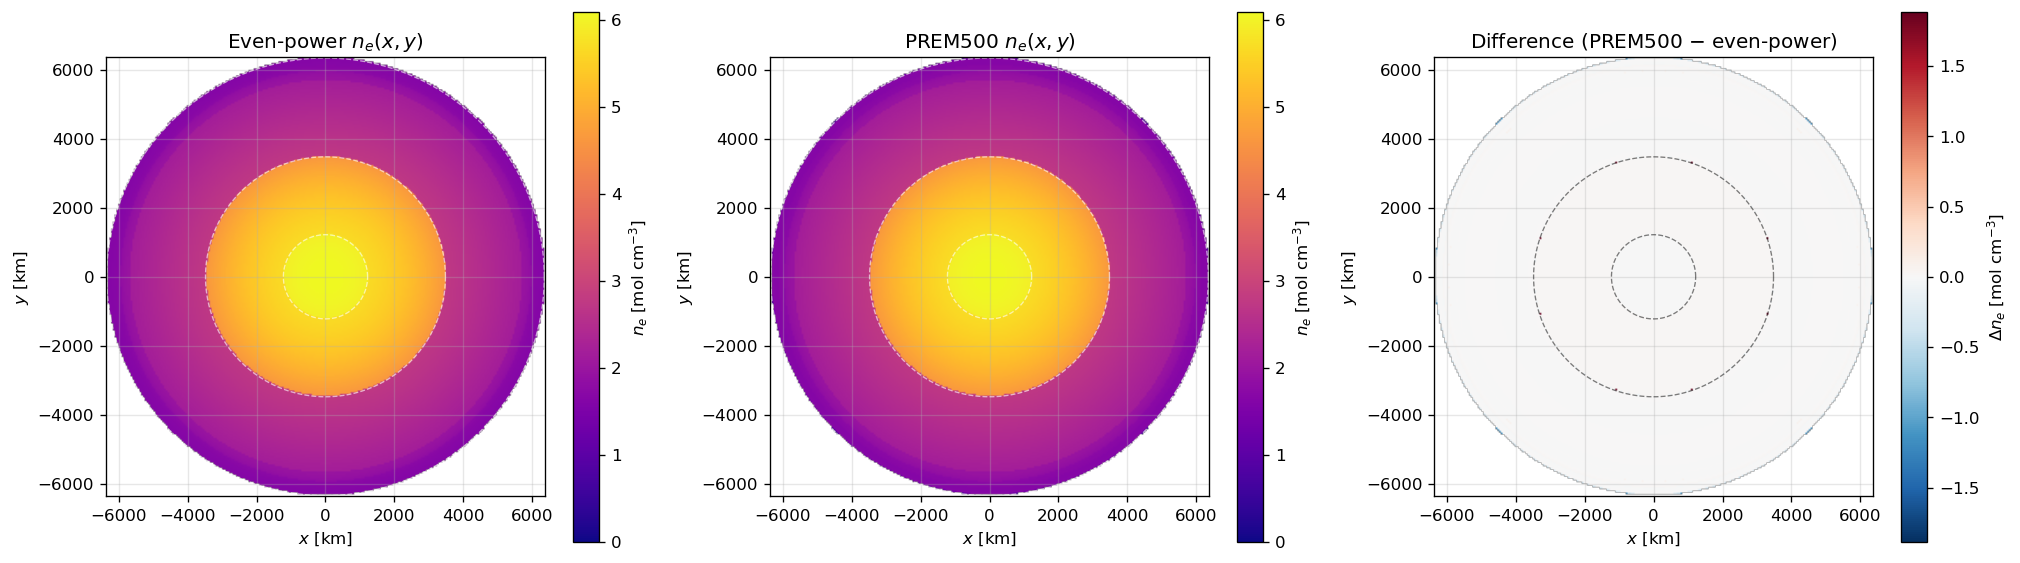

v:\output\analysis\earth\eg1_fig7_2d_cross_section.png
2D cross-section statistics (PREM):
  Grid: 250x250, cell size: 51.0 km
  Core peak n_e   : 6.094 mol/cm³
  Max |Δn_e| (2D) : 1.888 mol/cm³


In [16]:
NXY   = 250
xy_km = np.linspace(-R_E_KM, R_E_KM, NXY)
XX, YY = np.meshgrid(xy_km, xy_km)
RR_km  = np.sqrt(XX**2 + YY**2)
RR_norm = RR_km / R_E_KM
inside  = RR_norm <= 1.0

ne_2d_even = np.full((NXY, NXY), np.nan)
ne_2d_prem = np.full((NXY, NXY), np.nan)

r_inside_t = torch.tensor(RR_norm[inside], dtype=ctx.dtype, device=ctx.device)
eta0_t     = torch.tensor(0.0, dtype=ctx.dtype, device=ctx.device)
ne_2d_even[inside] = earth_even.density_x_eta(r_inside_t, eta0_t).cpu().numpy()
ne_2d_prem[inside] = earth_prem.density_x_eta(r_inside_t, eta0_t).cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

vmax = np.nanmax(ne_2d_prem)
for ax, data, title in [
    (axes[0], ne_2d_even, 'Even-power $n_e(x,y)$'),
    (axes[1], ne_2d_prem, 'PREM $n_e(x,y)$'),
]:
    im = ax.imshow(data, origin='lower', extent=[-R_E_KM, R_E_KM, -R_E_KM, R_E_KM],
                   cmap='plasma', vmin=0, vmax=vmax, interpolation='bilinear')
    # Overlay layer boundaries
    for r_km_b, dlabel in [(ICB_KM, 'ICB'), (CMB_KM, 'CMB'), (MOHO_KM, 'Moho')]:
        theta = np.linspace(0, 2 * np.pi, 200)
        ax.plot(r_km_b * np.cos(theta), r_km_b * np.sin(theta),
                'w--', lw=0.8, alpha=0.6)
    fig.colorbar(im, ax=ax, label=r'$n_e$ [mol cm$^{-3}$]', shrink=0.85)
    ax.set_xlabel('$x$ [km]')
    ax.set_ylabel('$y$ [km]')
    ax.set_title(title)

# Difference panel
diff = ne_2d_prem - ne_2d_even
vabs = np.nanmax(np.abs(diff))
im3 = axes[2].imshow(diff, origin='lower', extent=[-R_E_KM, R_E_KM, -R_E_KM, R_E_KM],
                     cmap='RdBu_r', vmin=-vabs, vmax=vabs, interpolation='bilinear')
for r_km_b in [ICB_KM, CMB_KM]:
    theta = np.linspace(0, 2 * np.pi, 200)
    axes[2].plot(r_km_b * np.cos(theta), r_km_b * np.sin(theta), 'k--', lw=0.8, alpha=0.5)
fig.colorbar(im3, ax=axes[2], label=r'$\Delta n_e$ [mol cm$^{-3}$]', shrink=0.85)
axes[2].set_xlabel('$x$ [km]')
axes[2].set_ylabel('$y$ [km]')
axes[2].set_title('Difference (PREM $-$ even-power)')

fig.tight_layout()
save_and_show('eg1_fig7_2d_cross_section.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f'2D cross-section statistics (PREM):')
print(f'  Grid: {NXY}x{NXY}, cell size: {2*R_E_KM/NXY:.1f} km')
print(f'  Core peak n_e   : {np.nanmax(ne_2d_prem):.3f} mol/cm³')
print(f'  Max |Δn_e| (2D) : {np.nanmax(np.abs(diff)):.3f} mol/cm³')

## 8. Summary

| Quantity | Even-power | PREM |
|----------|-----------|--------|
| Number of shells | small (~10) | 491 |
| Shell width range | broad | ~13 km uniform |
| Core $n_e$ [mol/cm³] | *(see §3.1)* | *(see §3.1)* |
| Max $|\Delta n_e|$ | — | *(see §3.3)* |
| Column density at $\eta=0$ [mol/cm²] | *(see §6.2)* | *(see §6.2)* |
| Max column-density ratio | — | *(see §6.2)* |

*(Run the notebook cells to fill in the exact values.)*

**Physical interpretation:**

1. Both density models agree at the $<5\%$ level for the column density at all nadir angles — the integrated effect of the profile choice on time-averaged matter-regeneration probabilities is small.

2. The critical angles $\eta_{\rm ICB} \approx 79°$ and $\eta_{\rm CMB} \approx 57°$ divide the neutrino population into three classes: core-crossing (most matter), mantle-only, and crust-skimming. Only the first two classes carry significant Earth matter-regeneration effects for atmospheric neutrinos.

3. The matter potential $V_{\rm CC}(r)$ crosses the atmospheric MSW resonance condition $\cos 2\theta_{13}\,\Delta m^2_{32}/2E$ at the core–mantle boundary region for $E \sim 3$–$7$ GeV. This resonance enhances the Earth matter effect and is the target of next-generation atmospheric-neutrino detectors (ORCA, PINGU, DUNE).

4. The 2D cross-section map confirms the spherical symmetry of both models and visually shows the layer structure and discontinuity sharpness.

In [17]:
print('Summary — Earth Analysis 1: Geometry and Density Profiles')
print('=' * 65)
print(f'Even-power shells : {len(rj_even_km)}')
print(f'PREM shells    : {len(rj_prem_km)}')
print(f'Core n_e (even)   : {ne_even[0]:.3f} mol/cm³')
print(f'Core n_e (PREM)   : {ne_prem[0]:.3f} mol/cm³')
print(f'V_mat at core (PREM): {ne_prem[0] * VMAT_CONV_EV / VMAT_SCALE:.3f} x10⁻¹³ eV')
print(f'Max residual |Δn_e|: {np.max(np.abs(delta_ne)):.3f} mol/cm³')
print()
print('Critical nadir angles:')
for name, r_km_b in BOUNDARIES:
    print(f'  {name:<30} r={r_km_b:6.1f} km -> eta_c={eta_crit_deg[name]:.1f}°')
print()
print('Column density at key nadir angles (PREM):')
for eta_d in [0, 30, 57, 79, 89]:
    idx = np.argmin(np.abs(ETA_SCAN_DEG - eta_d))
    print(f'  eta={eta_d:2d}°  N={col_prem[idx]:.3e} mol/cm²  phi={phi_prem[idx]:.4e} eV')

Summary — Earth Analysis 1: Geometry and Density Profiles
Even-power shells : 5
PREM shells    : 491
Core n_e (even)   : 6.099 mol/cm³
Core n_e (PREM)   : 6.094 mol/cm³
V_mat at core (PREM): 4.651 x10⁻¹³ eV
Max residual |Δn_e|: 1.888 mol/cm³

Critical nadir angles:
  ICB (IC/OC)                    r=1221.5 km -> eta_c=78.9°
  CMB (OC/Mantle)                r=3480.0 km -> eta_c=56.9°
  D'' base                       r=3630.0 km -> eta_c=55.3°
  660-km discontinuity           r=5711.0 km -> eta_c=26.3°
  410-km discontinuity           r=5961.0 km -> eta_c=20.7°
  Moho (Mantle/Crust)            r=6346.6 km -> eta_c=5.0°

Column density at key nadir angles (PREM):
  eta= 0°  N=5.184e+09 mol/cm²  phi=3.9566e-04 eV
  eta=30°  N=3.305e+09 mol/cm²  phi=2.5229e-04 eV
  eta=57°  N=1.427e+09 mol/cm²  phi=1.0890e-04 eV
  eta=79°  N=3.807e+08 mol/cm²  phi=2.9057e-05 eV
  eta=89°  N=6.264e+06 mol/cm²  phi=4.7808e-07 eV
